In [1]:
from vv.data import CIFAR10Loader, MNISTLoader
from vv.models import Autoencoder
from vv.models.fundamental import *
from vv.utilities import get_dir
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import chisquare

./venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = "CIFAR10"

In [3]:
if data == "CIFAR10":
    data_size = [3, 32, 32]
elif data == "MNIST":
    data_size = [1, 28, 28]

# Model

### Base encoder

In [ ]:
base_encoder = LinearEncoder(input_size=data_size,
                             hidden_layer_sizes=[650, 500, 400],
                             output_size = 350,
                             dropout_prob=0.0,
                             batch_norm=True)

In [ ]:
base_encoder = ConvolutionalEncoder(input_size=data_size,
                                    output_size = 500,
                                    channels = [3, 8, 16, 32],
                                    kernel_sizes = [3, 3, 3],
                                    strides = [1, 1, 1],
                                    pooling_sizes = [2, 2, 2],
                                    pooling_layer = "max",
                                    dropout_prob=0.0,
                                    batch_norm=True)

In [4]:
base_encoder = ResEncoder(input_size=data_size,
                          output_units=10,
                          dropout_prob=0.0,
                          batch_norm=True)

### Encoder

In [ ]:
encoder = base_encoder

In [ ]:
encoder = VariationalEncoder(base_encoder = base_encoder)

In [11]:
encoder = VQEncoder(base_encoder = base_encoder,
                    codebook_splits=[10, 11, 11],
                    separate_codebooks=[True, False, False],
                    codebook_size=512,
                    decoder_encoder_ste=True,
                    use_commitment_loss=True,
                    vq_loss="mse",
                    embedding_loss_weight=0.25)

### Decoder

In [ ]:
decoder = LinearDecoder(input_size = 350,
                        hidden_layer_sizes=[400, 500, 650],
                        output_size=data_size,
                        dropout_prob=0.0,
                        batch_norm=True)

In [ ]:
decoder = ConvolutionalDecoder(input_size=500,
                               output_size = data_size,
                               channels = [32, 16, 8, 3],
                               kernel_sizes = [3, 3, 3],
                               strides = [1, 1, 1],
                               upsampling_sizes = [2, 2, 2],
                               dropout_prob=0.0,
                               batch_norm=True)

In [7]:
decoder = ResDecoder(output_size=data_size,
                     input_units=10,
                     dropout_prob=0.0,
                     batch_norm=True)

### Full model

In [12]:
checkpoint_path = get_dir("models",
                          "Res_VQ_512_10_11_11_DCB",
                          "version_0",
                          "checkpoints",
                          "epoch=729-val_loss=0.00.ckpt")

model = Autoencoder.load_from_checkpoint(checkpoint_path=checkpoint_path,
                                         encoder=encoder,
                                         decoder=decoder,
                                         latent_error_weight=0.00,
                                         learning_rate=1e-3,
                                         lr_patience=10,
                                         check_val_every_n_epoch=5)

# Visualizing the embedding space

In [15]:
# Extract embedding space and embedding space shape
codebook_splits = model.encoder.quantizer.codebook_splits
in_out_shape = model.encoder.quantizer.in_out_shape

embedding_space = model.encoder.quantizer.embedding_space.squeeze(0).to("cpu").detach()

embedding_size = embedding_space.shape[-1]

print(in_out_shape)
print(embedding_size)
print(embedding_space.shape)

(10, 11, 11)
1
torch.Size([512, 10, 1, 1, 1, 1, 1])


In [16]:
def plot_2D_embedding(embedding_space,
                      quantization_head):
    embedding_space_copy = embedding_space[quantization_head].clone().numpy()

    fig, axs = plt.subplots(embedding_space_copy.shape[0], figsize=(5, 20))
    for i in range(embedding_space_copy.shape[0]):
            axs[i].hist(embedding_space_copy[i], bins=30)
            axs[i].set_title(f'Embedding ({i})', fontsize=10)
            axs[i].tick_params(axis='x', labelsize=8)
            low_val, high_val = axs[i].get_xlim()
            max_val = max(abs(low_val), abs(high_val))
            axs[i].set_xlim(-max_val, max_val)
            axs[i].set_xticks([-abs(max_val), 0, abs(max_val)])
            axs[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.3f}'.format(x)))
            axs[i].set_ylim(0, 400)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_2D_embedding_indiv(embedding_space,
                            quantization_head,
                            channel_number):
    embedding_space_copy = embedding_space[quantization_head, channel_number].clone().numpy()

    fig, axs = plt.subplots(11, 11, figsize=(20, 20))
    for i in range(11):
        for j in range(11):
            axs[i, j].hist(embedding_space_copy[i, j], bins=30)
            axs[i, j].set_title(f'Embedding ({i}, {j})', fontsize=10)
            axs[i, j].tick_params(axis='x', labelsize=8)
            low_val, high_val = axs[i, j].get_xlim()
            max_val = max(abs(low_val), abs(high_val))
            axs[i, j].set_xlim(-max_val, max_val)
            axs[i, j].set_xticks([-abs(max_val), 0, abs(max_val)])
            axs[i, j].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.3f}'.format(x)))
            axs[i, j].set_ylim(0, 200)
    plt.tight_layout()
    plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chisquare
import matplotlib.ticker as ticker

def gaussian(x, mu, sigma, a):
    return a * np.exp(-0.5 * ((x - mu) / sigma)**2)

def plot_quantisation_head_embedding(embedding_space):
    embedding_space_copy = embedding_space.view(-1).numpy()

    fig, ax = plt.subplots()
    counts, bins, _ = ax.hist(embedding_space_copy, bins=50, color="royalblue", alpha=0.6, label='Data')
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Fit the Gaussian distribution
    popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[0.0, 1.0, max(counts)])
    mu, sigma, a = popt

    # Calculate chi-squared
    expected_counts = gaussian(bin_centers, *popt)
    expected_counts *= counts.sum() / expected_counts.sum()  # Normalize expected counts
    chi2, p_value = chisquare(counts, f_exp=expected_counts)
    print(len(counts))
    dof = len(counts) - len(popt)
    chi2_red = chi2 / dof

    # Plot the fit
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    y_fit = gaussian(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label=f'Fit: μ={mu:.2f}, σ={sigma:.2f}, a={a:.2f}\nχ²={chi2:.2f}, χ²_red={chi2_red:.2f}, p={p_value:.2f}')

    # Debugging
    print(p_value)

    ax.set_title(f'Distribution of values across codebooks', fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', labelsize=12)
    low_val, high_val = ax.get_xlim()
    max_val = max(abs(low_val), abs(high_val))
    ax.set_xlim(-max_val, max_val)
    ax.set_xticks([-abs(max_val), 0, abs(max_val)])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.2f}'.format(x)))

    plt.xlabel('Codebook values', fontsize=14, fontweight='bold')
    plt.ylabel('Count', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

    # Adjust y-axis limit
    ax.set_ylim(0, 1.3 * max(counts))

    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.savefig('../plots/quantization_head_0.png')
    plt.show()

[  1.   0.   5.   0.   6.   5.   7.  13.   9.  17.  22.  29.  37.  41.
  56.  74.  98. 154. 175. 194. 221. 260. 290. 304. 315. 318. 317. 309.
 294. 276. 238. 202. 179. 164. 121.  86.  68.  53.  37.  29.  25.  19.
  13.  11.   9.   3.   8.   2.   4.   2.]
6.730538139623923e-27


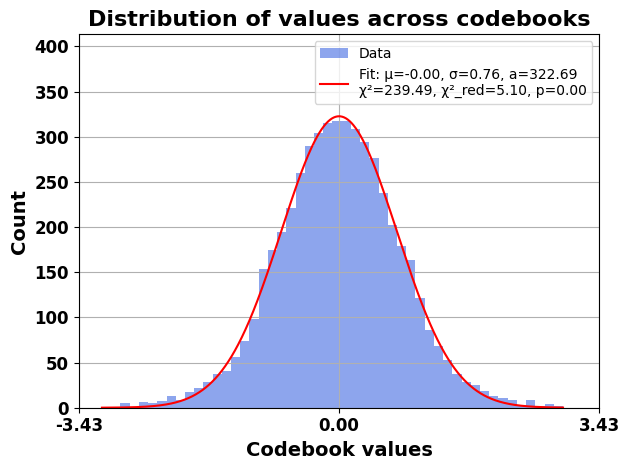

In [30]:
plot_quantisation_head_embedding(embedding_space=embedding_space)

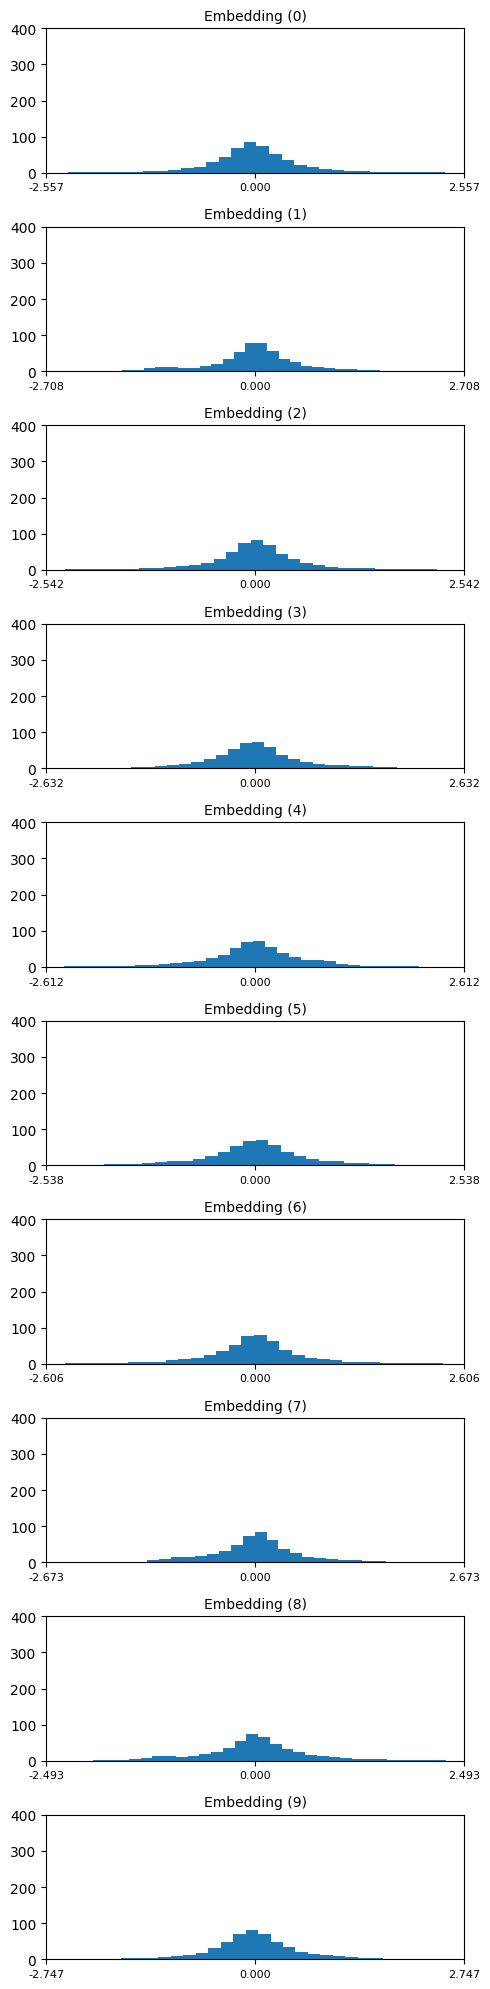

In [24]:
plot_2D_embedding(embedding_space,
                  quantization_head=0)